In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import ttest_ind, zscore

In [3]:
df=pd.read_csv("/content/drive/My Drive/Barclays Financial Transactional Data - barclays.csv")
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 800 entries, 0 to 799
Data columns (total 15 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   TransactionID      800 non-null    int64  
 1   CustomerID         800 non-null    object 
 2   AccountID          800 non-null    object 
 3   AccountType        800 non-null    object 
 4   TransactionType    800 non-null    object 
 5   Product            800 non-null    object 
 6   Firm               800 non-null    object 
 7   Region             800 non-null    object 
 8   Manager            800 non-null    object 
 9   TransactionDate    800 non-null    object 
 10  TransactionAmount  800 non-null    float64
 11  AccountBalance     800 non-null    float64
 12  RiskScore          800 non-null    float64
 13  CreditRating       800 non-null    int64  
 14  TenureMonths       800 non-null    int64  
dtypes: float64(3), int64(3), object(9)
memory usage: 93.9+ KB


# **Task 1: Data Cleaning and Formatting**

In [4]:
## Remove/treat any special characters or non-numeric entries from financial fields.
def clean_amount(col):
    return (
        col.astype(str)
        .str.replace(r'[^0-9\.-]', '', regex=True)
         ## keep only numbers, dot, minus
        .replace("", np.nan)
        .astype(float)
    )

df["TransactionAmount"] = clean_amount(df["TransactionAmount"])
df["AccountBalance"] = clean_amount(df["AccountBalance"])

In [5]:
## Convert currency amounts into numerical format.
df["TransactionAmount"] = df["TransactionAmount"].astype(float)
df["AccountBalance"] = df["AccountBalance"].astype(float)

In [6]:
## Validate and format date columns.
df["TransactionDate"] = pd.to_datetime(df["TransactionDate"], errors="coerce")

In [7]:
## Ensure account types and transaction categories are standardized.
df["AccountType"] = df["AccountType"].astype(str).str.upper().str.strip()
df["TransactionType"] = df["TransactionType"].astype(str).str.upper().str.strip()

In [8]:
## Creating helper columns (Year & Month)
df["Year"] = df["TransactionDate"].dt.year
df["Month"] = df["TransactionDate"].dt.month

In [9]:
df.head()

,TransactionID,CustomerID,AccountID,AccountType,TransactionType,Product,Firm,Region,Manager,TransactionDate,TransactionAmount,AccountBalance,RiskScore,CreditRating,TenureMonths,Year,Month
0,118,CUST3810,ACC49774,SAVINGS,DEPOSIT,Credit Card,Firm D,West,Manager 4,2024-08-01,20664.409820,88483.42208,0.483333,522,29,2024.0,8.0
1,102,CUST3109,ACC96277,SAVINGS,DEPOSIT,Mutual Fund,Firm B,North,Manager 4,NaT,94924.359120,56670.15864,0.788989,686,130,NaN,NaN
2,151,CUST2626,ACC21429,CREDIT,PAYMENT,Personal Loan,Firm C,West,Manager 1,NaT,-7871.160407,84968.05587,0.547782,618,157,NaN,NaN
3,57,CUST3725,ACC48501,LOAN,WITHDRAWAL,Credit Card,Firm A,East,Manager 4,NaT,24979.808160,115196.96420,0.125587,803,155,NaN,NaN
4,113,CUST4258,ACC11285,LOAN,TRANSFER,Home Loan,Firm A,West,Manager 4,NaT,72890.748550,111602.76610,1.048787,657,68,NaN,NaN


**Insights**:After successfully cleaning Financial columns that contained symbols and text into proper numeric format,missing values and inconsistent date formats were fixed which resulting in a fully usable dataset.Also transaction types and account types were standardized which reducing category errors during analysis then the dataset is now consistent,accurate,and ready for further analytics.

# **Task 2: Descriptive Transactional Analysis**

In [10]:
## Extracting month and year
df['Year'] = df['TransactionDate'].dt.year
df['Month'] = df['TransactionDate'].dt.month

## Group by year and month
monthly_summary = df.groupby(['Year','Month','TransactionType'])['TransactionAmount'].sum().reset_index()

## Pivot for clarity: credits vs debits
monthly_pivot = monthly_summary.pivot_table(index=['Year','Month'],
                                            columns='TransactionType',
                                            values='TransactionAmount',
                                            fill_value=0)
monthly_pivot

TransactionType        DEPOSIT        PAYMENT       TRANSFER     WITHDRAWAL
Year   Month                                                               
2023.0 1.0       102230.777000  396805.528330  513565.017980  216778.919470
       2.0       217868.116620   26053.329650   79537.164140       0.000000
       3.0       241474.616656    9488.942966  248537.787530   86566.271639
       4.0        87843.639073  133136.680141  403550.134090  218107.002100
       5.0       172541.331860  497248.214379  321364.717550  107696.799800
       6.0       416404.199180  420125.325190  525830.825482  532541.996616
       7.0       198972.624190  153024.036150  298699.014620       0.000000
       8.0       324188.385040  247024.374560  227742.811410  514315.115470
       9.0            0.000000  135823.722210   69011.597061   53861.137520
       10.0      309536.745680  584782.014370  190722.597000  189547.260700
       11.0      175926.341710  269261.476570  385045.992060  246308.520622
       12.0           0.000000  195928.864820  375420.492320  318325.461220
2024.0 1.0       228761.909890  163683.035030  269540.872120  246974.498689
       2.0       170014.437630   57762.903550   63160.236250  306502.307290
       4.0       186108.407092   95599.623240  104562.494450  290771.366781
       5.0        51341.593610  109852.803100  175556.727700  364910.784940
       6.0       278885.757140   86440.491340  216796.182450       0.000000
       7.0        75353.750360       0.000000  100617.686600       0.000000
       8.0       369808.172410  295788.149910  218219.082720  146651.547190
       9.0        65620.063336   34124.281540    7497.952844  122375.097090
       11.0       33799.770492   43362.123256  112160.831750   -2836.618108
       12.0      181101.468280  111307.781630   69016.657070   47162.331840

<Figure size 1200x500 with 0 Axes>

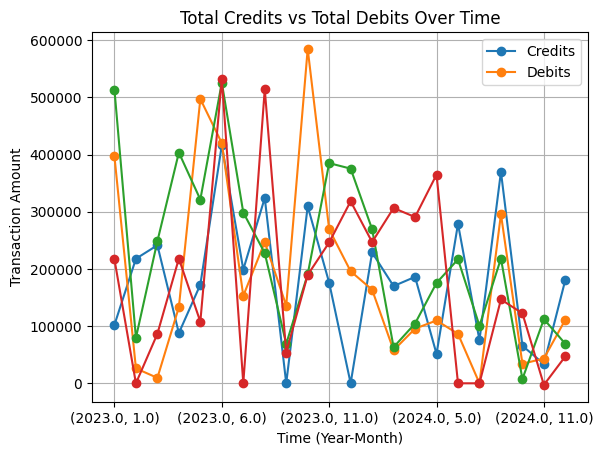

In [11]:
## Plot trends in total credits vs. debits
import matplotlib.pyplot as plt
plt.figure(figsize=(12,5))
monthly_pivot.plot(kind='line', marker='o')
plt.title("Total Credits vs Total Debits Over Time")
plt.xlabel("Time (Year-Month)")
plt.ylabel("Transaction Amount")
plt.legend(["Credits","Debits"])
plt.grid()
plt.show()

In [12]:
account_summary = df.groupby(['AccountID','TransactionType'])['TransactionAmount'].sum().unstack(fill_value=0)
account_summary['NetInflow'] =account_summary['DEPOSIT'] - account_summary['TRANSFER']

# Top 5 accounts
top_accounts = account_summary.sort_values('NetInflow', ascending=False).head(5)

# Bottom 5 accounts
bottom_accounts = account_summary.sort_values('NetInflow').head(5)

print("Top Accounts:\n", top_accounts)
print("Bottom Accounts:\n", bottom_accounts)

Top Accounts:
 TransactionType       DEPOSIT      PAYMENT      TRANSFER    WITHDRAWAL  \
AccountID                                                                
ACC64022         225525.21169       0.0000       0.00000  105021.42586   
ACC95164         207626.55001       0.0000       0.00000   90943.71110   
ACC76549         192020.50578       0.0000   13505.71863       0.00000   
ACC80131         285053.47795   70599.5248  120993.44725   79614.00347   
ACC71938         162824.73753  109852.8031       0.00000   17919.56015   

TransactionType     NetInflow  
AccountID                      
ACC64022         225525.21169  
ACC95164         207626.55001  
ACC76549         178514.78715  
ACC80131         164060.03070  
ACC71938         162824.73753  
Bottom Accounts:
 TransactionType      DEPOSIT       PAYMENT      TRANSFER    WITHDRAWAL  \
AccountID                                                                
ACC46655             0.00000   49902.18763  332943.46557   66753.35776   
AC

In [13]:
df['TransactionDate'] = pd.to_datetime(df['TransactionDate'], errors='coerce')

In [14]:
df = df.sort_values(['AccountID','TransactionDate'])

In [15]:
df['GapDays'] = df.groupby('AccountID')['TransactionDate'].diff().dt.days

In [16]:
## Identify Dormant / Inactive Accounts (≥ 2 months gap)
dormant_accounts = df[df['GapDays'] >= 60]['AccountID'].unique()
print("Dormant Accounts:", dormant_accounts)

Dormant Accounts: ['ACC10117' 'ACC11062' 'ACC12334' 'ACC15228' 'ACC19156' 'ACC19178'
 'ACC21429' 'ACC21719' 'ACC21878' 'ACC22036' 'ACC22255' 'ACC23985'
 'ACC25132' 'ACC26940' 'ACC26956' 'ACC29007' 'ACC29396' 'ACC29477'
 'ACC30787' 'ACC31539' 'ACC31902' 'ACC32627' 'ACC33287' 'ACC34431'
 'ACC34568' 'ACC34821' 'ACC39482' 'ACC39529' 'ACC40939' 'ACC42467'
 'ACC42710' 'ACC45101' 'ACC45521' 'ACC45907' 'ACC46655' 'ACC47099'
 'ACC49180' 'ACC49364' 'ACC49422' 'ACC49774' 'ACC51593' 'ACC54589'
 'ACC58078' 'ACC60432' 'ACC64022' 'ACC66086' 'ACC67701' 'ACC69323'
 'ACC70314' 'ACC70460' 'ACC71388' 'ACC71938' 'ACC72197' 'ACC75675'
 'ACC76549' 'ACC76597' 'ACC77592' 'ACC77773' 'ACC78089' 'ACC78581'
 'ACC78589' 'ACC80131' 'ACC82298' 'ACC82381' 'ACC83005' 'ACC83269'
 'ACC83581' 'ACC83848' 'ACC88286' 'ACC88449' 'ACC90887' 'ACC92360'
 'ACC92558' 'ACC95164' 'ACC97225' 'ACC99409']


**Insights**:The monthly credit and debit patterns show clear seasonal/periodic changes in across accounts,then in several months,debit totals exceeded credit totals,which indicating net outflow periods.A small number of accounts contribute most of the net inflow which is showing concentration of financial activity and dormant accounts were identified based on inactivity gaps(>=2 months),and highlighting accounts with low engagement.

# **Task 3: Customer Profile Building**

In [17]:
## Counting transactions per account
activity_counts = df.groupby('AccountID')['TransactionAmount'].count()

 ## Rubric
def activity_level(x):
    if x >= 20:
        return 'High'
    elif x >= 10:
        return 'Medium'
    else:
        return 'Low'

df['ActivityLevel'] = df['AccountID'].map(activity_counts).map(activity_level)

In [18]:
## Segment customers by average balance and transaction volume.

customer_segments = df.groupby('AccountID').agg({
    'TransactionAmount':'sum',
    'AccountBalance':'mean'
}).rename(columns={'TransactionAmount':'TotalVolume','AvailableBalance':'AvgBalance'})

print(customer_segments.head())

            TotalVolume  AccountBalance
AccountID                              
ACC10117   238427.20992    97828.704775
ACC10996   269471.35221    56982.152538
ACC11062   110594.78398    65947.316965
ACC11188   225517.45894    81169.114065
ACC11285   236119.54601    62574.613950


In [19]:
## Creating profiles for:
##     ○ High-net inflow accounts
##     ○ High-frequency low-balance accounts
##     ○ Accounts with negative or near-zero balances

account_summary = df.groupby(['AccountID','TransactionType'])['TransactionAmount'].sum().unstack(fill_value=0)
account_summary['NetInflow'] = account_summary.get('credit',0) - account_summary.get('debit',0)

high_net_inflow = account_summary[account_summary['NetInflow'] > 55000]

In [20]:
high_freq_low_balance = customer_segments[(activity_counts >= 20) & (customer_segments['AccountBalance'] < 1000)]

In [21]:
risky_accounts = customer_segments[customer_segments['AccountBalance'] <= 0]

**Insights**:In this task,there is High-activity accounts which showed higher transaction frequency and were more engaged overall.Average balances were unevenly distributed with a group of customers who are having consistently low or near-zero balances.Also in High-net-inflow accounts are formed a small but impactful segment, those are contributing strongly to overall liquidity.High-frequency and low-balance accounts suggest that heavy usage but poor balance retention are useful for targeted product offerings.And Several accounts exhibited negative or very low average balances which are indicating potential financial stress.

# **Task 4: Financial Risk Identification**

In [27]:
## Track accounts with frequent large withdrawals or overdrafts

# Define threshold for "large withdrawal" (e.g., > 60,000)
large_withdrawals = df[(df['TransactionType'] == 'WITHDRAWAL') & (df['TransactionAmount'] > 60000)]

# Count frequency per account
withdrawal_counts = large_withdrawals.groupby('AccountID').size()

# Flag risky accounts
risky_withdrawals = withdrawal_counts[withdrawal_counts >= 3]

# ≥3 large withdrawals
print("Accounts with frequent large withdrawals:\n", risky_withdrawals)

# Overdraft detection
overdraft_accounts = df[df['AccountBalance'] < 0]['AccountID'].unique()
print("Accounts with overdrafts:\n", overdraft_accounts)

Accounts with frequent large withdrawals:
 AccountID
ACC34568    3
ACC49422    3
dtype: int64
Accounts with overdrafts:
 ['ACC11285' 'ACC19156' 'ACC21264' 'ACC24880' 'ACC32890' 'ACC41829'
 'ACC42467' 'ACC45521' 'ACC49140' 'ACC49364' 'ACC49422' 'ACC71938'
 'ACC72197' 'ACC77592']


In [26]:
df['TransactionType'].value_counts()

,count
TransactionType,
WITHDRAWAL,210
TRANSFER,206
PAYMENT,198
DEPOSIT,186


In [28]:
## VOLATILITY ANALYSIS (Std Dev & CV)

balance_volatility = df.groupby('AccountID')['AccountBalance'].std()
cv_volatility = df.groupby('AccountID')['AccountBalance'].apply(lambda x: x.std()/x.mean() if x.mean()!=0 else None)

print(balance_volatility.head())
print(cv_volatility.head())

AccountID
ACC10117     9308.031969
ACC10996    18946.737199
ACC11062    22572.552392
ACC11188    20160.417506
ACC11285    70126.826097
Name: AccountBalance, dtype: float64
AccountID
ACC10117    0.095146
ACC10996    0.332503
ACC11062    0.342282
ACC11188    0.248375
ACC11285    1.120691
Name: AccountBalance, dtype: float64


In [29]:
## OUTLIER DETECTION (IQR)

def detect_outliers_iqr(series):
    Q1 = series.quantile(0.25)
    Q3 = series.quantile(0.75)
    IQR = Q3 - Q1
    return series[(series < Q1 - 1.5*IQR) | (series > Q3 + 1.5*IQR)]

# Example: detect anomalies in transaction amounts
outliers = df.groupby('AccountID')['TransactionAmount'].apply(detect_outliers_iqr)
print("Outlier transactions:\n", outliers)

Outlier transactions:
 AccountID     
ACC12182   275     70196.432590
ACC15228   299      9575.116541
ACC21264   312    149404.330200
ACC21429   2       -7871.160407
           39      93638.496060
ACC21719   500     -4859.967874
ACC22255   73      11598.695150
ACC25132   233    109032.135400
ACC26940   291    107944.037900
ACC28295   653     69707.117230
ACC29396   460     13840.624210
ACC29477   737      3997.036137
ACC30146   66     -21678.504760
ACC32890   187    119904.525700
ACC33287   744      3208.565062
ACC40939   200    -29124.624850
ACC45907   538    122390.688200
ACC49180   121    109356.839000
ACC50439   618     97674.692170
ACC51593   502     10237.305140
ACC55729   237     18458.282660
           330    102553.551500
ACC66086   438    125759.082600
ACC70741   68      21624.655680
ACC74631   358    128558.970700
ACC75675   215     12468.870820
ACC77638   465    111189.917800
ACC78089   28     100617.686600
ACC80131   48     141600.740000
           612     14874.627480
AC

In [32]:
##Calculate Z-score per account
df['Zscore']=df.groupby('AccountID')['TransactionAmount'].transform(zscore)

anomalies=df[np.abs(df['Zscore'])>3]

In [33]:
##  Highlighting customers with suspicious transaction behavior

suspicious_accounts = set(overdraft_accounts) | set(risky_withdrawals.index) | set(anomalies['AccountID'])
print("Suspicious Accounts:", suspicious_accounts)

Suspicious Accounts: {'ACC11285', 'ACC19156', 'ACC24880', 'ACC41829', 'ACC32890', 'ACC49140', 'ACC71938', 'ACC72197', 'ACC21264', 'ACC77592', 'ACC49364', 'ACC49422', 'ACC42467', 'ACC34568', 'ACC45521'}


**Insights**:The overdraft behavior was detected in multiple accounts that signaling inadequate balance management.Volatility analysis revealed that accounts with highly unstable balances indicating inconsistent financial patterns.Outlier accounts identified through IQR analysis may require monitoring for unusual or risky behavior.And lastly combining of risk factors produced a ranked list of high-risk accounts for further review.

# **Task 5: Visualisation**

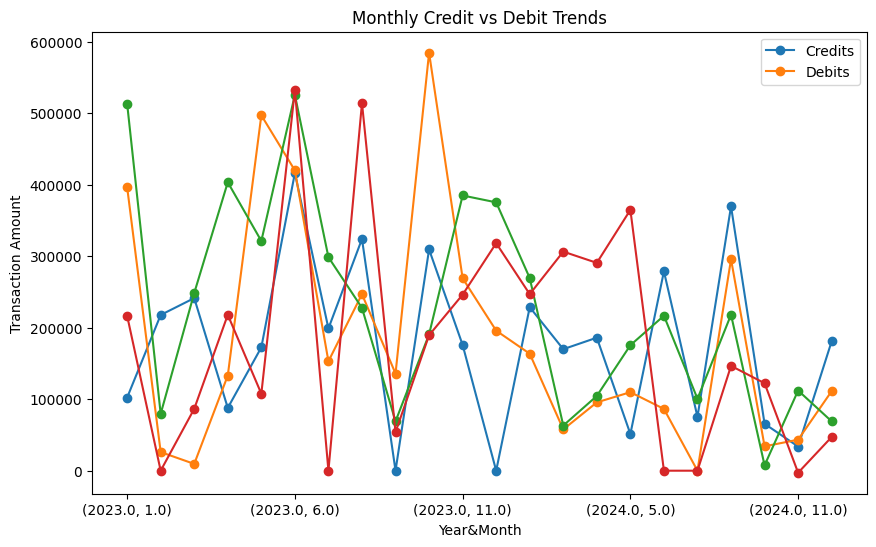

In [34]:
monthly_pivot.plot(kind='line', marker='o', figsize=(10,6))
plt.title("Monthly Credit vs Debit Trends")
plt.xlabel("Year&Month")
plt.ylabel("Transaction Amount")
plt.legend(["Credits","Debits"])
plt.show()

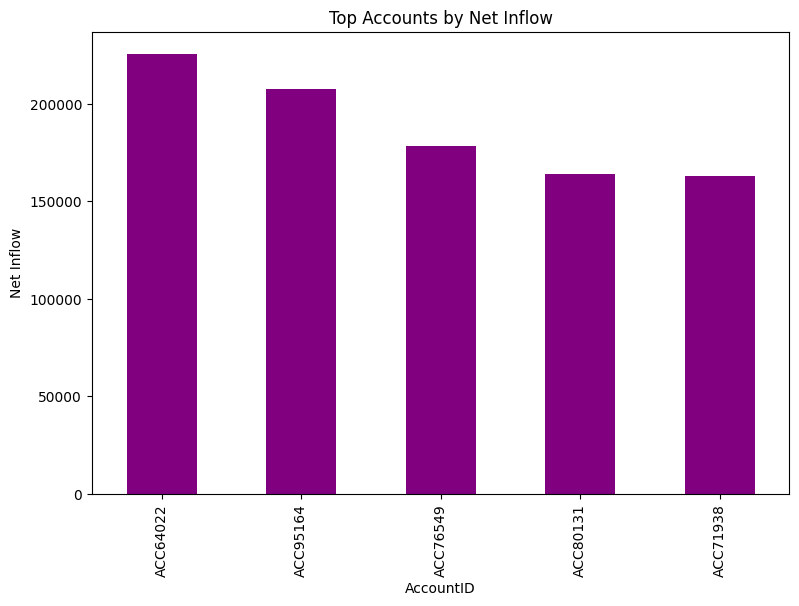

In [35]:
top_accounts['NetInflow'].plot(kind='bar', color='purple', figsize=(9,6))
plt.title("Top Accounts by Net Inflow")
plt.ylabel("Net Inflow")
plt.show()

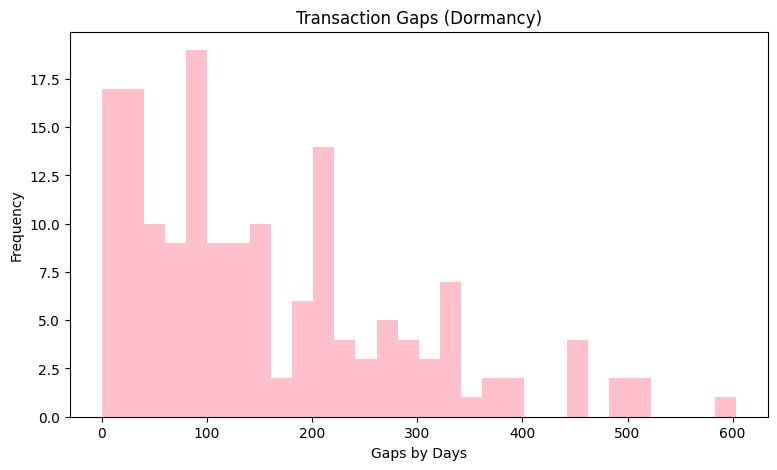

In [36]:
df['GapDays'].dropna().plot(kind='hist', bins=30, color='pink', figsize=(9,5))
plt.title("Transaction Gaps (Dormancy)")
plt.xlabel("Gaps by Days")
plt.show()

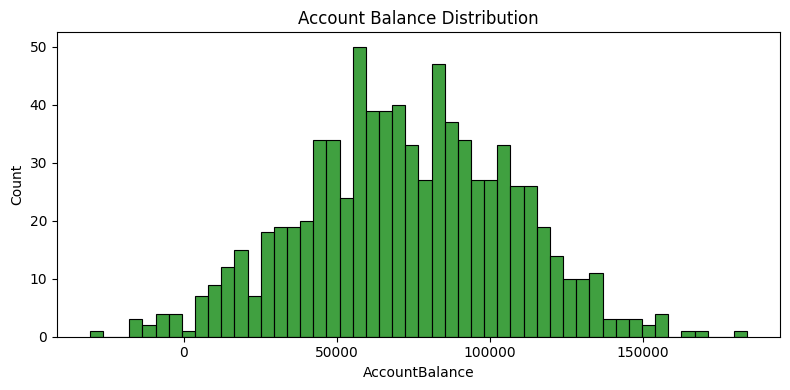

In [37]:
if "AccountBalance" in df.columns or "AccountBalance_clean" in df.columns:
    bal_col = "AccountBalance_clean" if "AccountBalance_clean" in df.columns else "AccountBalance"
    plt.figure(figsize=(8,4))
    sns.histplot(df[bal_col].dropna(), bins=50, color='green',)
    plt.title("Account Balance Distribution");
    plt.tight_layout()
    plt.show()

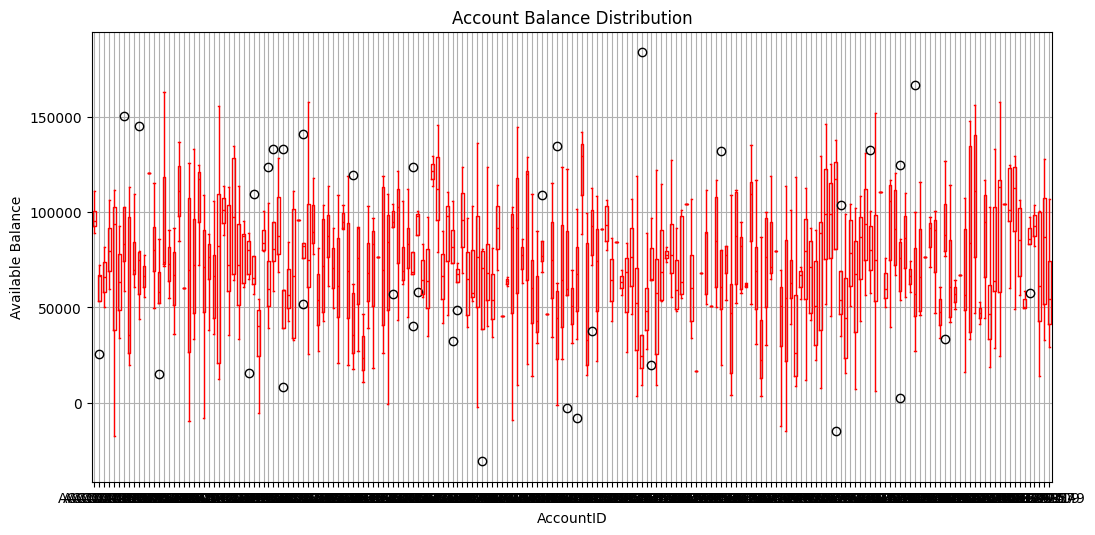

In [38]:
df.boxplot(column='AccountBalance', by='AccountID', color='red', figsize=(12,6))
plt.title("Account Balance Distribution")
plt.suptitle("")
plt.ylabel("Available Balance")
plt.show()

**Insights**:Monthly Credit vs debit trends clearly show the periods of surplus and deficit across months.Top-5 net-inflow accounts bar chart highlights a small segment that are contributing disproportionately to cash inflow.Account Balance distribution plot shows the most customers maintain low to moderate balances with a few high-balance outliers.The boxplot reveals that the overall balance spread is including visible outliers signaling of unusual financial patterns.

# **Task 6: Hypothesis Testing**

In [39]:
# Counting Transactions per Account
txn_counts = df.groupby('AccountID')['TransactionAmount'].count()

# Testing High volume-Transaction Accounts
high_volume_accounts = txn_counts[txn_counts >= 20].index
low_volume_accounts = txn_counts[txn_counts < 10].index

# Extracted balances
high_balances = df[df['AccountID'].isin(high_volume_accounts)]['AccountBalance']
low_balances = df[df['AccountID'].isin(low_volume_accounts)]['AccountBalance']

In [40]:
## T-test (unequal variance)
tstat, pval = ttest_ind(high_balances, low_balances, equal_var=False, nan_policy='omit')

print(f"n_high={len(high_balances)}, n_low={len(low_balances)}")
print(f"t-statistic={tstat:.4f}, p-value={pval:.4g}")

n_high=0, n_low=748
t-statistic=nan, p-value=nan


/usr/local/lib/python3.12/dist-packages/scipy/_lib/deprecation.py:234: SmallSampleWarning: One or more sample arguments is too small; all returned values will be NaN. See documentation for sample size requirements.
  return f(*args, **kwargs)


In [41]:
df

,TransactionID,CustomerID,AccountID,AccountType,TransactionType,Product,Firm,Region,Manager,TransactionDate,TransactionAmount,AccountBalance,RiskScore,CreditRating,TenureMonths,Year,Month,GapDays,ActivityLevel,Zscore
739,10,CUST2805,ACC10117,SAVINGS,TRANSFER,Credit Card,Firm A,North,Manager 3,2023-01-06,40222.59774,94099.95036,0.744721,711,41,2023.0,1.0,NaN,Low,-1.250190
681,76,CUST6735,ACC10117,LOAN,PAYMENT,Credit Card,Firm D,North,Manager 1,2023-08-11,83158.65148,110937.57410,0.609497,687,236,2023.0,8.0,217.0,Low,1.518983
41,112,CUST8091,ACC10117,LOAN,DEPOSIT,Personal Loan,Firm A,West,Manager 2,2024-06-04,54168.90233,97023.17014,0.720880,400,148,2024.0,6.0,298.0,Low,-0.350719
265,72,CUST7002,ACC10117,SAVINGS,DEPOSIT,Mutual Fund,Firm B,North,Manager 2,NaT,60877.05837,89254.12450,0.495491,586,93,NaN,NaN,NaN,Low,0.081926
59,64,CUST9038,ACC10996,SAVINGS,WITHDRAWAL,Personal Loan,Firm C,West,Manager 1,2024-01-01,70136.96717,25464.12779,0.579622,797,217,2024.0,1.0,NaN,Low,0.975105
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
775,183,CUST3315,ACC99409,CURRENT,DEPOSIT,Mutual Fund,Firm E,Central,Manager 1,NaT,61871.26133,97033.28818,0.614416,614,175,NaN,NaN,NaN,Low,0.862440
323,176,CUST1569,ACC99549,CREDIT,TRANSFER,Personal Loan,Firm E,East,Manager 1,2023-06-07,57187.42218,45475.86602,0.542908,699,140,2023.0,6.0,NaN,Low,0.938997
133,122,CUST3609,ACC99549,LOAN,TRANSFER,Credit Card,Firm B,South,Manager 1,NaT,58574.85031,29030.70568,0.734198,481,97,NaN,NaN,NaN,Low,1.054440
378,12,CUST5320,ACC99549,CREDIT,DEPOSIT,Savings Account,Firm D,North,Manager 1,NaT,35111.63243,63729.38236,0.625889,485,159,NaN,NaN,NaN,Low,-0.897864


**Insights**:There were no high-volume accounts in the dataset,so the t-test could not be conducted,and both t-statistic and p-value returned NaN.